In [1]:
import requests
from urllib.parse import unquote

BASE = "https://apiv2-observatorio.sebrae.com.br/tesseract/data.jsonrecords"
MUN = "3550308"  # São Paulo

queries = [
    # Empresas por setor e clientes Sebrae
    f"{BASE}?Registration+Status=2&Sebrae+Target+Audience+Indicator=1&Grande+Sector=1,2,3,4&cube=RF&drilldowns=Sebrae+Client+Indicator,Grande+Sector&locale=pt&measures=Establishments&Municipality={MUN}",
    # Empresas por natureza jurídica
    f"{BASE}?Municipality={MUN}&Registration+Status=2&cube=RF&drilldowns=Legal+Nature&measures=Establishments&parents=true&exclude=Type+Legal+Nature:0",
    # Evolução de novas empresas por ano e porte
    f"{BASE}?Municipality={MUN}&Registration+Status=2&cube=RF&drilldowns=Open+Activity+Year,Company+Size+Sebrae&measures=Establishments&time=Open+Activity+Year.gte.1980&exclude=Company+Size+Sebrae:0",
    # Empresas por porte e setor (matriz para SAM)
    f"{BASE}?Municipality={MUN}&Registration+Status=2&cube=RF&drilldowns=Grande+Sector,Company+Size+Sebrae&measures=Establishments&exclude=Company+Size+Sebrae:0",
    # CAGED - movimentações por setor 2026
    f"{BASE}?Municipality={MUN}&Grande+Sector=1,2,3,4,5&Year=2026&cube=CAGED_movements&drilldowns=Grande%20Sector&measures=Movement+Balance,Admissions,Resignations",
    # RAIS - empregados e remuneração por setor/ano (MPE)
    f"{BASE}?Municipality={MUN}&Aggregated+Company+Size=1&Commercial+Companies+Indicator=1&cube=RAIS_workers&drilldowns=Grande%20Sector,Year&measures=Remuneration+Avg+Nominal,Workers&Active+worker+indicator=1",
    # RAIS - distribuição por subgrupo 2023 vs 2024
    f"{BASE}?Active+worker+indicator=1&Commercial+Companies+Indicator=1&Aggregated+Company+Size=1&Municipality={MUN}&Year=2023,2024&cube=RAIS_workers&drilldowns=Year,Subgroup,Active+worker+indicator&measures=Workers,Remuneration+Avg+Nominal&parents=true&growth=Year.Workers.fixed.2023",
    # IBGE - pirâmide etária (Censo 2022)
    f"{BASE}?Municipality={MUN}&Year=2022&cube=IBGE_Censo_Sexo_Faixa_Etaria&drilldowns=Age+Group,Sex&locale=pt&measures=Population",
    # IBGE - evolução populacional município
    f"{BASE}?Municipality={MUN}&cube=IBGE_Censo_Pop_Sit&drilldowns=Year,Municipality&locale=pt&measures=Population",
    # PNUD - Índice Gini município
    f"{BASE}?Year=2000,2010&Municipality={MUN}&cube=PNUD_Atlas_IDHM&drilldowns=Year,Municipality&locale=pt&measures=Gini",
    # INEP - distorção idade-série
    f"{BASE}?Education+Level=0,3&Municipality={MUN}&cube=INEP_Censo_Taxas_Basica&drilldowns=Year,Education+Level&locale=pt&measures=Age-Grade+Distortion+Rate",
    # INEP - abandono escolar
    f"{BASE}?Education+Level=0,3&Municipality={MUN}&cube=INEP_Censo_Taxas_Basica&drilldowns=Year%2CEducation+Level&locale=pt&measures=Dropout+Rate",
]


def get_param(url, name):
    """Extrai e decodifica um parâmetro da query string."""
    for part in url.split("?", 1)[1].split("&"):
        if part.startswith(name + "="):
            return unquote(part.split("=", 1)[1].replace("+", " "))
    return ""


all_data = {}
for url in queries:
    r = requests.get(url)
    data = r.json()
    cube = get_param(url, "cube")
    measures = get_param(url, "measures")
    drilldowns = get_param(url, "drilldowns")
    # Chave única: cube + measures + drilldowns evita colisão entre queries do mesmo cubo
    key = f"{cube}__{measures}__{drilldowns}"
    all_data[key] = data
    print(f"✅ {key}: {data['page']['total']} registros")

✅ RF__Establishments__Sebrae Client Indicator,Grande Sector: 8 registros


✅ RF__Establishments__Legal Nature: 72 registros


✅ RF__Establishments__Open Activity Year,Company Size Sebrae: 188 registros


✅ RF__Establishments__Grande Sector,Company Size Sebrae: 22 registros


✅ CAGED_movements__Movement Balance,Admissions,Resignations__Grande Sector: 5 registros


...

✅ IBGE_Censo_Sexo_Faixa_Etaria__Population__Age Group,Sex: 42 registros


✅ IBGE_Censo_Pop_Sit__Population__Year,Municipality: 6 registros


✅ PNUD_Atlas_IDHM__Gini__Year,Municipality: 2 registros


✅ INEP_Censo_Taxas_Basica__Age-Grade Distortion Rate__Year,Education Level: 14 registros


✅ INEP_Censo_Taxas_Basica__Dropout Rate__Year,Education Level: 14 registros


In [2]:
import requests
cubes = requests.get("https://apiv2-observatorio.sebrae.com.br/tesseract/cubes").json()
for cube in cubes["cubes"]:
    print(cube["name"], "—", cube["annotations"].get("table", ""))

INEP_Censo_Ed_Basica — Censo da Educação Básica
PCI — 
IBGE_Censo_Pop_Sit — Pop por Situação Domiciliar
DATASUS_Estimativas_Populacionais — Estimativas Populacionais
credito_bacen_valores — Credito
Relatedness — 
Sebrae_Atendimento — Atendimentos
PPM Efetivo dos Rebanhos — PPM - Efetivo dos Rebanhos
Digital_Market_Comparation — Comparativo de Pesquisas
IBGE_Censo_Densidade_Demografica — Densidade demográfica
IBGE_PIB_Municipal_VAB — PIB Municipal - Valor Adicionado Bruto
ANATEL_IBC_MUN — IBC MUN - Normalizado
bcb_sicor_prod — SICOR - Valores Contratos por Produto
radar_predictions — Previsões
PEVS_Plant_Extraction — Extração Vegetal
MTUR_Mapa_Turismo — Mapa do Turismo
SICONFI_receitas — Receitas
PEVS_Area_Forestry — Área Total Silvicultura
INEP_enem — ENEM
rf_notas_fiscais — Notas Fiscais
INEP_Censo_Taxas_Basica — Taxas - Educação Básica
CAGED_movements — Movimentação
MTUR_Chegadas_Internacionais — Chegadas Internacionais
BCB_AGENCIAS_POSTOS — BCB - Agências e Postos
PNUD_Atlas_IDHM 

In [3]:
with open("../data/raw/sebrae.json", "w", encoding="utf-8") as f:
    import json
    json.dump(all_data, f, indent=2, ensure_ascii=False)

In [7]:
import sys, os
sys.path.append(os.path.abspath(".."))  # acesso a src/
import pandas as pd
import matplotlib.pyplot as plt
from src import sebrae
from src import market_sizing as ms

raw = sebrae.load_raw("../data/raw/sebrae.json")

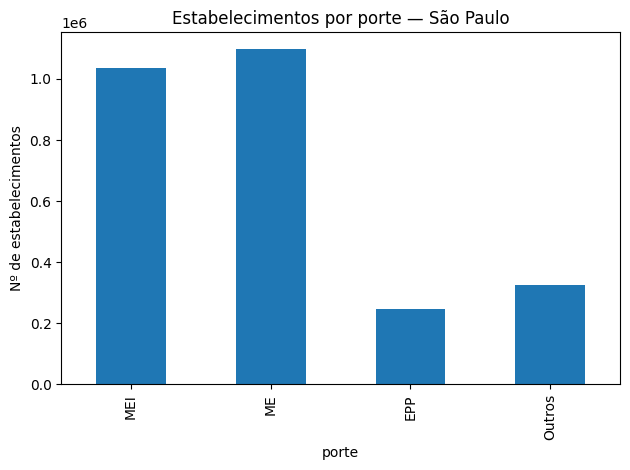

porte
MEI       1037246.0
ME        1097821.0
EPP        246204.0
Outros     325925.0
Name: Establishments, dtype: float64

In [8]:
# df_porte_ano (porte×ano, filtrado por ano de abertura >= 1980): usado só na curva temporal.
df_porte_ano = sebrae.clean_portes(
    sebrae.to_df(raw, "RF__Establishments__Open Activity Year,Company Size Sebrae")
)
# df_ps (porte×setor, universo completo): base da composição por porte, do SAM e do TAM.
df_ps = sebrae.clean_portes(
    sebrae.to_df(raw, "RF__Establishments__Grande Sector,Company Size Sebrae")
)
# Composição por porte usa o universo completo, consistente com o TAM.
comp = df_ps.groupby("porte")["Establishments"].sum().reindex(
    ["MEI", "ME", "EPP", "Outros"]
)
ax = comp.plot.bar(title="Estabelecimentos por porte — São Paulo")
ax.set_ylabel("Nº de estabelecimentos")
plt.tight_layout(); plt.show()
comp

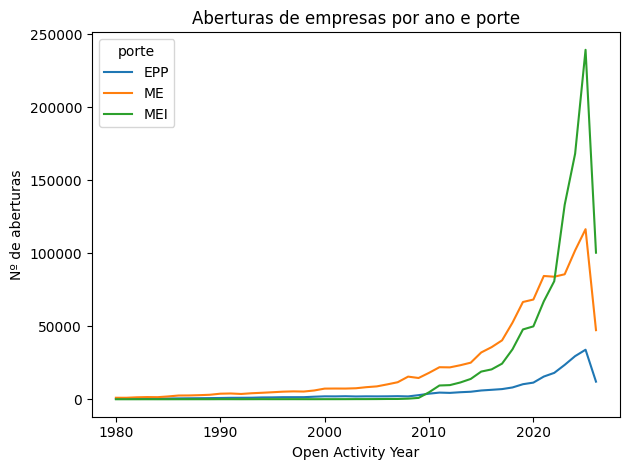

In [6]:
curva = (df_porte_ano[df_porte_ano["porte"].isin(["MEI", "ME", "EPP"])]
         .pivot_table(index="Open Activity Year", columns="porte",
                      values="Establishments", aggfunc="sum"))
ax = curva.plot(title="Aberturas de empresas por ano e porte")
ax.set_ylabel("Nº de aberturas")
plt.tight_layout(); plt.show()

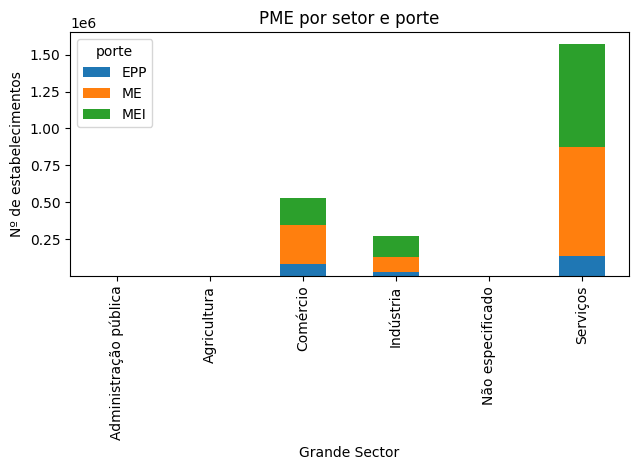

porte,EPP,ME,MEI
Grande Sector,,,
Administração pública,3.0,8.0,0.0
Agricultura,150.0,773.0,1793.0
Comércio,82905.0,261220.0,186542.0
Indústria,25805.0,100118.0,147482.0
Não especificado,17.0,1193.0,0.0
Serviços,137324.0,734509.0,701429.0


In [7]:
# df_ps já definido acima (porte×setor). Distribuição setorial das PME:
pivot = df_ps[df_ps["porte"].isin(["MEI", "ME", "EPP"])].pivot_table(
    index="Grande Sector", columns="porte", values="Establishments", aggfunc="sum"
).fillna(0)
ax = pivot.plot.bar(stacked=True, title="PME por setor e porte")
ax.set_ylabel("Nº de estabelecimentos")
plt.tight_layout(); plt.show()
pivot

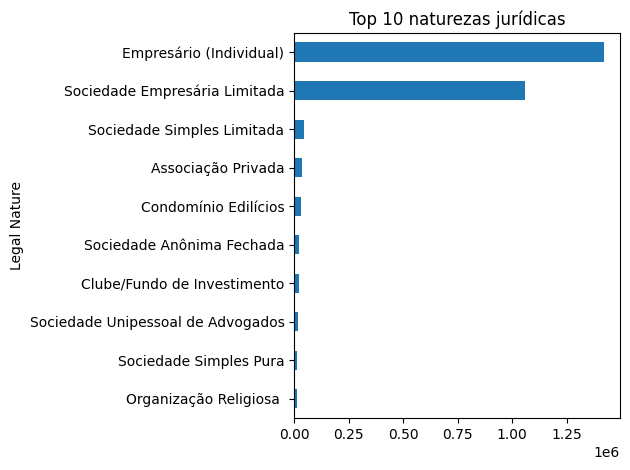

Legal Nature
Empresário (Individual)              1423833.0
Sociedade Empresária Limitada        1057365.0
Sociedade Simples Limitada             45124.0
Associação Privada                     35260.0
Condomínio Edilícios                   33238.0
Sociedade Anônima Fechada              22903.0
Clube/Fundo de Investimento            22732.0
Sociedade Unipessoal de Advogados      15986.0
Sociedade Simples Pura                 12860.0
Organização Religiosa                  11440.0
Name: Establishments, dtype: float64

In [8]:
nat = sebrae.to_df(raw, "RF__Establishments__Legal Nature")
top = nat.groupby("Legal Nature")["Establishments"].sum().nlargest(10)
ax = top.sort_values().plot.barh(title="Top 10 naturezas jurídicas")
plt.tight_layout(); plt.show()
top

In [9]:
cli = sebrae.to_df(raw, "RF__Establishments__Sebrae Client Indicator,Grande Sector")
pen = cli.pivot_table(index="Grande Sector", columns="Sebrae Client Indicator",
                      values="Establishments", aggfunc="sum").fillna(0)
pen["% cliente"] = 100 * pen.get("Sim", 0) / pen.sum(axis=1)
pen

Sebrae Client Indicator,Não,Sim,% cliente
Grande Sector,,,
Agricultura,2443.0,265.0,9.785820
Comércio,380521.0,149981.0,28.271524
Indústria,210588.0,62712.0,22.946213
Serviços,1342177.0,229916.0,14.624835


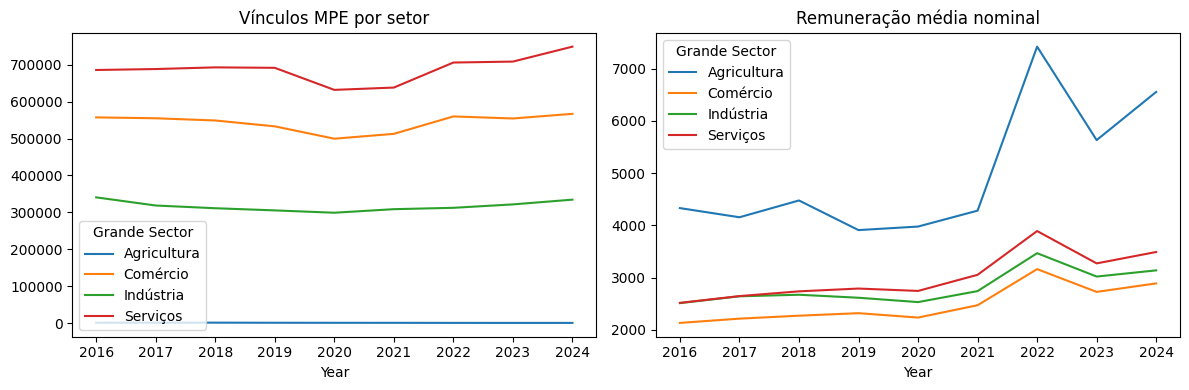

In [10]:
rais = sebrae.to_df(raw, "RAIS_workers__Remuneration Avg Nominal,Workers__Grande Sector,Year")
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
rais.pivot_table(index="Year", columns="Grande Sector", values="Workers", aggfunc="sum").plot(ax=ax[0], title="Vínculos MPE por setor")
rais.pivot_table(index="Year", columns="Grande Sector", values="Remuneration Avg Nominal", aggfunc="mean").plot(ax=ax[1], title="Remuneração média nominal")
plt.tight_layout(); plt.show()

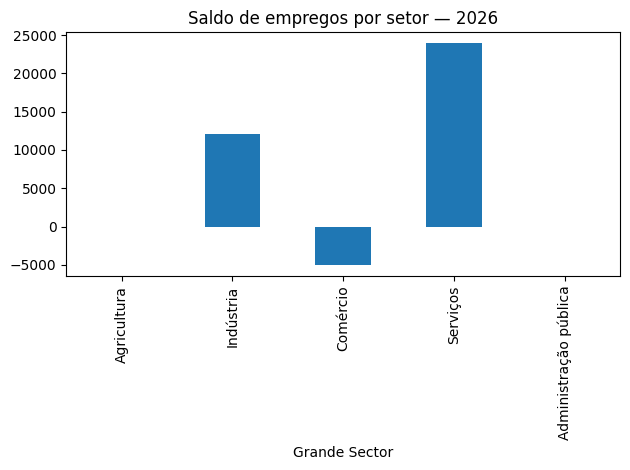

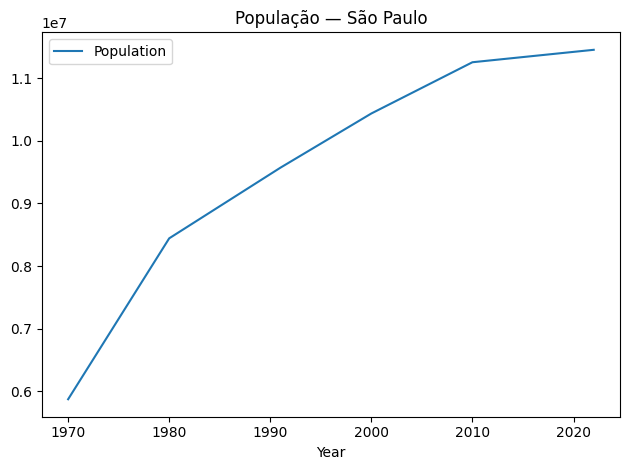

,Grande Sector ID,Grande Sector,Admissions,Movement Balance,Resignations
0,1,Agricultura,284.0,11.0,273.0
1,2,Indústria,73462.0,12120.0,61342.0
2,3,Comércio,80101.0,-4992.0,85093.0
3,4,Serviços,337467.0,23905.0,313562.0
4,5,Administração pública,155.0,-28.0,183.0


In [11]:
caged = sebrae.to_df(raw, "CAGED_movements__Movement Balance,Admissions,Resignations__Grande Sector")
ax = caged.set_index("Grande Sector")["Movement Balance"].plot.bar(title="Saldo de empregos por setor — 2026")
plt.tight_layout(); plt.show()

pop = sebrae.to_df(raw, "IBGE_Censo_Pop_Sit__Population__Year,Municipality")
pop.plot(x="Year", y="Population", title="População — São Paulo"); plt.tight_layout(); plt.show()
caged

In [12]:
# === PREMISSAS — TODO calibrar ===
PRECOS_MENSAIS = [None]            # TODO: ex. [50, 100, 200] R$/PME/mês
TAXAS_SOM = {"pessimista": None,   # TODO: ex. 0.01
             "base": None,         # TODO: ex. 0.03
             "otimista": None}     # TODO: ex. 0.05

In [13]:
# TAM e SAM derivam do MESMO dataset (porte×setor, universo completo) para
# garantir consistência do funil TAM >= SAM. O porte×ano (filtrado por ano de
# abertura >= 1980) serve apenas para a curva temporal de aberturas, não para o total.
tam = ms.compute_tam(
    df_ps.groupby("porte", as_index=False)["Establishments"].sum()
)
sam_df = ms.compute_sam(df_ps, sebrae.SAM_SETORES)
sam_total = sam_df["sam"].sum()
print("TAM (PME):", tam["tam_pme"])
print("SAM (Com+Serv+Ind):", sam_total)
assert tam["tam_pme"] >= sam_total, "Invariante do funil violado: TAM < SAM"
sam_df

TAM (PME): 2381271.0
SAM (Com+Serv+Ind): 2377334.0


,setor,sam
0,Comércio,530667.0
1,Indústria,273405.0
2,Serviços,1573262.0


In [14]:
if all(v is not None for v in TAXAS_SOM.values()):
    som_df = ms.compute_som(sam_total, TAXAS_SOM)
    display(som_df)
else:
    print("Defina TAXAS_SOM para calcular o SOM.")
    som_df = None

Defina TAXAS_SOM para calcular o SOM.


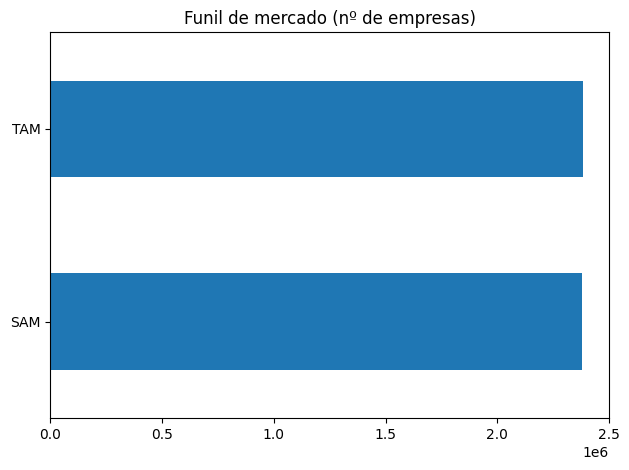

{'TAM': 2381271.0, 'SAM': 2377334.0}

In [15]:
estagios = {"TAM": tam["tam_pme"], "SAM": sam_total}
if som_df is not None:
    estagios["SOM (base)"] = float(som_df.set_index("cenario").loc["base", "som"])
ax = pd.Series(estagios).plot.barh(title="Funil de mercado (nº de empresas)")
ax.invert_yaxis(); plt.tight_layout(); plt.show()
estagios

In [16]:
if all(p is not None for p in PRECOS_MENSAIS):
    rev = {
        "TAM": ms.to_revenue(tam["tam_pme"], PRECOS_MENSAIS),
        "SAM": ms.to_revenue(sam_total, PRECOS_MENSAIS),
    }
    rev_df = pd.DataFrame(rev).T
    display(rev_df)
else:
    print("Defina PRECOS_MENSAIS para converter em R$.")
    rev_df = None

Defina PRECOS_MENSAIS para converter em R$.


In [17]:
import os
os.makedirs("../data/interim", exist_ok=True)

comp.to_frame("estabelecimentos").to_csv("../data/interim/pme_porte.csv")
pivot.to_csv("../data/interim/pme_porte_setor.csv")

funil = pd.DataFrame({"estagio": list(estagios), "n_empresas": list(estagios.values())})
funil.to_csv("../data/interim/tam_sam_som.csv", index=False)

contexto = rais.merge(caged[["Grande Sector", "Movement Balance"]], on="Grande Sector", how="left")
contexto.to_csv("../data/interim/contexto_socioecon.csv", index=False)
print("Saídas gravadas em data/interim/")

Saídas gravadas em data/interim/


In [18]:
totais_setor = (df_ps[df_ps["porte"].isin(["MEI","ME","EPP"])]
                .groupby("Grande Sector")["Establishments"].sum())
check = sam_df.set_index("setor")["sam"]
assert (check.reindex(check.index) <= totais_setor.reindex(check.index) + 1e-6).all()
print("Sanity check OK: SAM por setor consistente com totais.")

Sanity check OK: SAM por setor consistente com totais.
